#### 2. Airport Profiling Using Clustering (Machine Learning)

Using unsupervised machine learning (K-Means clustering) to group airports based on their delay patterns and cancellation rates.
This helps identify operational behavior of airports such as high-delay hubs or efficient airports

Unsupervised learning is a type of machine learning where the model is given data without labels and it tries to find patterns or structure on its own.

In [3]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans

In [4]:
# ============================================================
# STEP 1: LOAD DATA
# ============================================================

# Load dataset where each row represents one flight
flights_data = pd.read_csv('flight_data.csv')

In [5]:
# ============================================================
# STEP 2: DATA PREPARATION
# ============================================================

# Convert FL_DATE into datetime format
# WHY?
# → Required for time-based analysis (like trends over days/months)
flights_data['FL_DATE'] = pd.to_datetime(flights_data['FL_DATE'])

# Selecting only relevant columns
# WHY?
# → We only keep features related to delays and cancellations
# → Irrelevant features increase noise in clustering

relevant_columns = [
    'FL_DATE', 
    'ORIGIN',                      # Airport (we will cluster airports)
    'OP_CARRIER_AIRLINE_ID',      
    'DEP_DELAY', 
    'ARR_DELAY',
    'CARRIER_DELAY', 
    'WEATHER_DELAY', 
    'NAS_DELAY', 
    'SECURITY_DELAY', 
    'LATE_AIRCRAFT_DELAY', 
    'CANCELLED'
]

flights_data_filtered = flights_data[relevant_columns]

In [6]:
# ============================================================
# STEP 3: HANDLING MISSING VALUES
# ============================================================

# WHY fillna(0)?
# → If delay is missing, we assume "no delay recorded"
# → This is a domain-based assumption

# IMPORTANT (for viva):
# This is a simplification — in real systems, better imputation could be used

flights_data_filtered.fillna(0, inplace=True)

,FL_DATE,ORIGIN,OP_CARRIER_AIRLINE_ID,DEP_DELAY,ARR_DELAY,CARRIER_DELAY,WEATHER_DELAY,NAS_DELAY,SECURITY_DELAY,LATE_AIRCRAFT_DELAY,CANCELLED
0,2018-08-01,LAX,21167,-7.0,-4.0,0.0,0.0,0.0,0.0,0.0,0.0
1,2018-08-01,SMF,21167,-9.0,-8.0,0.0,0.0,0.0,0.0,0.0,0.0
2,2018-08-01,LAX,21167,-6.0,-13.0,0.0,0.0,0.0,0.0,0.0,0.0
3,2018-08-01,SMF,21167,-5.0,-12.0,0.0,0.0,0.0,0.0,0.0,0.0
4,2018-08-01,LAX,21167,-1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...
20306,2018-08-31,SJC,19687,-4.0,-6.0,0.0,0.0,0.0,0.0,0.0,0.0
20307,2018-08-31,SJC,19687,40.0,30.0,0.0,0.0,0.0,0.0,30.0,0.0
20308,2018-08-31,BUR,19687,-6.0,-5.0,0.0,0.0,0.0,0.0,0.0,0.0
20309,2018-08-31,BUR,19687,25.0,20.0,0.0,0.0,0.0,0.0,20.0,0.0


In [7]:
# ============================================================
# STEP 4: AGGREGATING DATA AT AIRPORT LEVEL
# ============================================================

# VERY IMPORTANT STEP

# WHY GROUP BY ORIGIN?
# → We are not clustering flights, we are clustering AIRPORTS
# → So we summarize all flights of an airport into one row

airport_delays = flights_data_filtered.groupby('ORIGIN').agg({
    'DEP_DELAY': 'mean',              # Average departure delay
    'ARR_DELAY': 'mean',              # Average arrival delay
    'CARRIER_DELAY': 'mean',          # Airline-related delay
    'WEATHER_DELAY': 'mean',          # Weather impact
    'NAS_DELAY': 'mean',              # Air traffic system delay
    'SECURITY_DELAY': 'mean',         # Security issues
    'LATE_AIRCRAFT_DELAY': 'mean',    # Previous aircraft delay
    'CANCELLED': 'mean'               # Cancellation rate
}).reset_index()

# RESULT:
# Each airport now has a "profile"
# Example:
# Airport A → high weather delay
# Airport B → high carrier delay

Clustering is a technique used to group similar data points together based on their features.

🧠 In this Project
- Each airport = one data point
- Features = delay types + cancellation rate
- Output = groups of similar airports

In [8]:
# ============================================================
# STEP 5: WHY CLUSTERING?
# ============================================================

# So we are using UNSUPERVISED LEARNING clustering method → K-MEANS

# K-Means is an algorithm that divides data into K clusters by minimizing the 
# distance between data points and their cluster center (centroid).

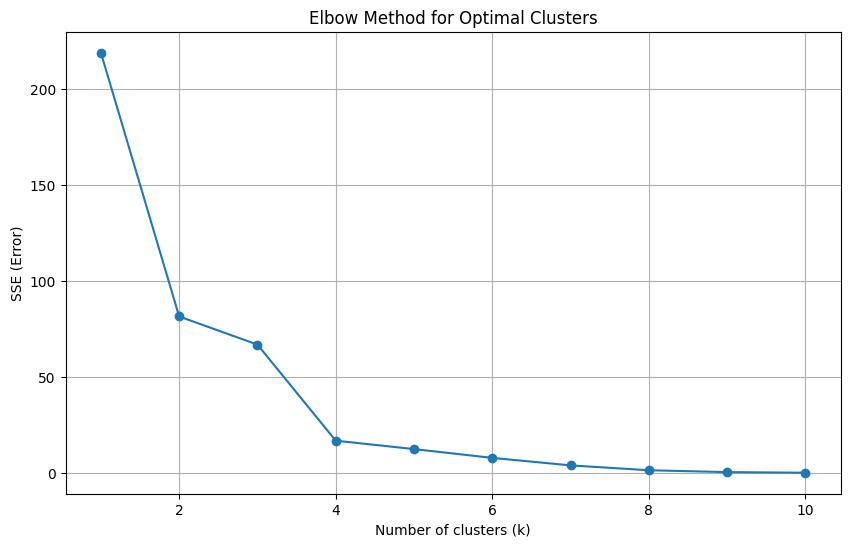

In [9]:
# ============================================================
# STEP 6: FIND OPTIMAL NUMBER OF CLUSTERS (ELBOW METHOD)
# ============================================================

# WHY DO WE NEED THIS?
# K-Means requires number of clusters (k)
# But we don’t know correct k beforehand

# A technique used to determine the optimal number of clusters (K)
# by plotting error vs number of clusters.

# As K increases → error decreases
# At some point → improvement slows
# That point = “elbow”

sse = []  # Sum of Squared Errors

for k in range(1, 11):
    kmeans = KMeans(n_clusters=k, random_state=42)

    # Fit model on numerical features (excluding ORIGIN)
    kmeans.fit(airport_delays.iloc[:, 1:])

    # inertia_ = total distance of points from their cluster center
    # Lower is better
    sse.append(kmeans.inertia_)

# Plot elbow curve
plt.figure(figsize=(10, 6))
plt.plot(range(1, 11), sse, marker='o')

plt.title('Elbow Method for Optimal Clusters')
plt.xlabel('Number of clusters (k)')
plt.ylabel('SSE (Error)')
plt.grid(True)
plt.show()

# INTERPRETATION:
# We look for "elbow point" → where improvement slows down
# In this case → k = 4

In [10]:
# ============================================================
# STEP 7: APPLY K-MEANS CLUSTERING
# ============================================================

# WHY K-MEANS?
# → Simple, fast, and effective for grouping similar data
# → Works well when clusters are spherical and well-separated

kmeans = KMeans(n_clusters=4, random_state=42)

# Assign cluster label to each airport
airport_delays['Cluster'] = kmeans.fit_predict(airport_delays.iloc[:, 1:])

In [12]:
# ============================================================
# STEP 8: UNDERSTANDING CLUSTERS
# ============================================================

# Each cluster has a "center" → represents average behavior

cluster_centers = kmeans.cluster_centers_

columns = airport_delays.columns[1:-1]

cluster_summary = pd.DataFrame(
    cluster_centers,
    columns=columns,
    index=[f'Cluster {i+1}' for i in range(4)]
)

print(cluster_summary)

# WHY THIS IS IMPORTANT?
# → Helps interpret clusters

# Example:
# Cluster 1 → low delays → efficient airports
# Cluster 4 → high delays → problematic airports

           DEP_DELAY  ARR_DELAY  CARRIER_DELAY  WEATHER_DELAY  NAS_DELAY  \
Cluster 1   7.623173   3.470134       2.716481       0.012409   1.076798   
Cluster 2  13.748206   9.374012       2.046459       0.027709   6.042333   
Cluster 3  10.943730   7.856789       2.773639       0.009061   4.465110   
Cluster 4  15.472027  11.501827       4.757380       0.008153   1.849873   

           SECURITY_DELAY  LATE_AIRCRAFT_DELAY  CANCELLED  
Cluster 1        0.021894             4.716132   0.015052  
Cluster 2        0.016447             5.767643   0.014493  
Cluster 3        0.007552             5.518349   0.024198  
Cluster 4        0.000000             9.765252   0.040484  


In [15]:
# ============================================================
# STEP 9: TIME-BASED ANALYSIS OF CLUSTERS
# ============================================================

# Merge cluster info back to flight-level data
flights_with_date = flights_data_filtered.merge(
    airport_delays[['ORIGIN', 'Cluster']],
    on='ORIGIN',
    how='left'
)

# Group by date and cluster
date_cluster_group = (
    flights_with_date
    .groupby(['FL_DATE', 'Cluster'])
    .mean(numeric_only=True)
    .reset_index()
)

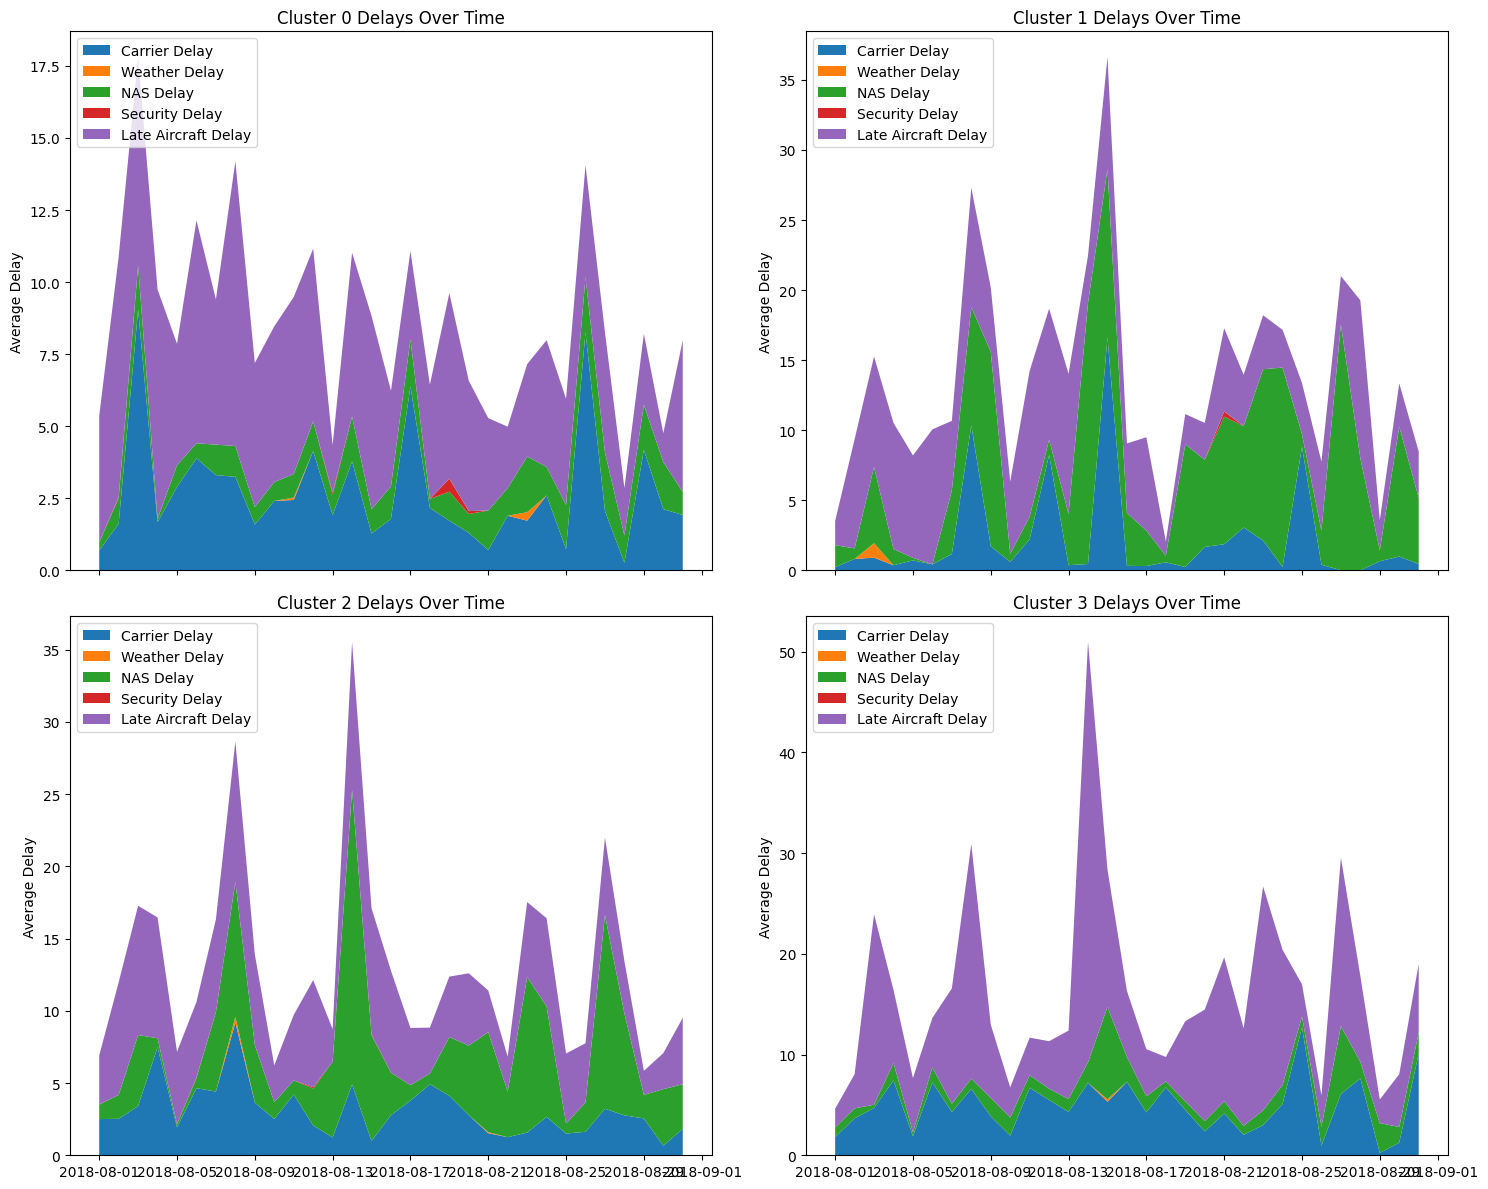

In [16]:
# ============================================================
# STEP 10: VISUALIZATION (AREA CHARTS)
# ============================================================

# WHY AREA CHART?
# → Shows contribution of different delay types over time

fig, axes = plt.subplots(2, 2, figsize=(15, 12), sharex=True)

clusters = sorted(date_cluster_group['Cluster'].unique())

for ax, cluster in zip(axes.flatten(), clusters):
    subset = date_cluster_group[date_cluster_group['Cluster'] == cluster]

    ax.stackplot(
        subset['FL_DATE'],
        subset['CARRIER_DELAY'],
        subset['WEATHER_DELAY'],
        subset['NAS_DELAY'],
        subset['SECURITY_DELAY'],
        subset['LATE_AIRCRAFT_DELAY'],
        labels=[
            'Carrier Delay',
            'Weather Delay',
            'NAS Delay',
            'Security Delay',
            'Late Aircraft Delay'
        ]
    )

    ax.set_title(f'Cluster {cluster} Delays Over Time')
    ax.set_ylabel('Average Delay')
    ax.legend(loc='upper left')

plt.tight_layout()
plt.show()

### Cluster 1: "High Efficiency, Low Impact"

Lowest Delays: This cluster features the lowest average departure and arrival delays, suggesting efficient operations and minimal disruptions.

Minimal Weather and NAS Delays: Both weather and NAS delays are extremely low, indicating that these airports are less affected by external environmental factors and airspace system issues.

Low Cancellations: The cancellation rate is also low, enhancing its reputation for reliability.

Insight: Airports in this cluster are likely smaller or exceptionally well-managed, with streamlined operations that rarely face significant delays or cancellations.

### Cluster 2: "Moderate Delays, Controlled Impact"

Higher Delays: Exhibits moderate levels of departure and arrival delays. Not as efficient as Cluster 1 but still manages to keep delays under control.

Higher NAS Delays: Indicates more significant impact from the National Airspace System, possibly due to higher traffic volumes or strategic location.

Low Carrier and Security Delays: Shows effective management of carrier operations and security, contributing to fewer delays in these areas despite higher overall delays.

Insight: These airports might be busier than those in Cluster 1 but have effective delay management strategies in place, particularly concerning carrier and security operations.

### Cluster 3: "Average Performance"

Intermediate Delays: Delays are higher than Cluster 1 but lower than Cluster 4, placing them in the middle in terms of operational efficiency.

Moderate Cancellation Rates: Has a higher cancellation rate compared to Clusters 1 and 2, which might indicate more frequent issues or challenges.

Balanced Delay Types: No particular type of delay dominates, suggesting a balanced spread of delay causes.

Insight: Airports in this cluster have average delay and cancellation rates, likely reflecting a mix of traffic volumes and operational challenges.

### Cluster 4: "High Delays and Cancellations"

Highest Delays: This cluster experiences the highest average departure and arrival delays.

Significant Late Aircraft Delays: The highest late aircraft delays, possibly indicating issues with scheduling, airline efficiency, or knock-on effects from earlier delays.

Highest Cancellations: Also features the highest cancellation rate, underscoring potential issues with reliability.

Insight: Airports in this cluster may struggle with operational efficiency and face the most significant challenges regarding managing delays and cancellations. They could benefit from targeted improvements in scheduling and operational coordination.